# Regularized CM at the optimal $\alpha^{*}$: restored scale invariance and fewer failures

Hard correlated matching (CM, $\alpha=1$) over-corrects at low $p$ and loses a unit of effective
distance. Regularized CM (RCM) damps the second-pass reweight with a strength $\alpha<1$; the
optimal $\alpha^{*}(p)$ is read from `data/reg_cm_alpha_scan_d3d5d7.csv`. This notebook repeats the
two hard-CM diagnostics with $\alpha^{*}$:

1. the broken-scale-invariance plot ($d=5$), adding the **RCM($\alpha^{*}$) posterior edge weight**;
2. the counts of low-weight configurations that confuse **CM($\alpha=1$)** vs **RCM($\alpha^{*}$)**
   vs **MWPM** ($d=5$ weight-2 exhaustive, $d=7$ weight-3 sampled).

The reweighted (posterior) edge probability with strength $\alpha$ is the Pearl soft-evidence mix
$$p_{\text{imp}} = \alpha\,P(e_\mu\!\mid\!e_\nu) + (1-\alpha)\,P(e_\mu\!\mid\!\neg e_\nu),\qquad
  w = \log\frac{1-p_{\text{imp}}}{p_{\text{imp}}},$$
exactly as implemented in the PyMatching fork (`analytical_cm_second_pass_weights`); at $\alpha=1$ it
reduces to the hard-evidence posterior $P(e_\mu\!\mid\!e_\nu)$.

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "figures_generation" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
import stim, pymatching
from NeuralCM.decompose_errors import decompose_errors_for_stim_surface_code_coords
from NeuralCM.decoding_graph import DecodingGraph

FIG = os.path.join(ROOT, "plots", "figures"); os.makedirs(FIG, exist_ok=True)
DATA = os.path.join(ROOT, "data")
CSV = os.path.join(DATA, "reg_cm_alpha_scan_d3d5d7.csv")
plt.rcParams.update({"font.size": 11, "figure.dpi": 110, "mathtext.fontset": "cm"})

df = pd.read_csv(CSV)


def best_alpha(d, p):
    "Optimal reweighting strength alpha*(p): the alpha < 1 minimising LER in the scan."
    s = df[(df.distance == d) & (np.abs(df.p - p) < 1e-12) & (df.decoder == "cm") & (df.alpha < 1.0)]
    return float(s.loc[s.ler.idxmin()].alpha) if len(s) else None


def build(D, P):
    circ = stim.Circuit.generated(
        "surface_code:rotated_memory_z", distance=D, rounds=D,
        after_clifford_depolarization=P, before_measure_flip_probability=P,
        after_reset_flip_probability=P, before_round_data_depolarization=P)
    dem = decompose_errors_for_stim_surface_code_coords(circ.detector_error_model(decompose_errors=False))
    mwpm = pymatching.Matching.from_detector_error_model(dem, enable_correlations=False)
    cm = pymatching.Matching.from_detector_error_model(dem, enable_correlations=True)
    return circ, dem, mwpm, cm


def mechanisms(dem):
    ND = dem.num_detectors; mechs, hyper = [], []
    for inst in dem.flattened():
        if inst.type != "error":
            continue
        dets, obs, sep = set(), 0, False
        for t in inst.targets_copy():
            if t.is_relative_detector_id(): dets ^= {t.val}
            elif t.is_logical_observable_id(): obs ^= 1
            elif t.is_separator(): sep = True
        mechs.append((frozenset(dets), obs)); hyper.append(sep)
    M = len(mechs)
    dm = np.zeros((M, ND), np.uint8); ob = np.zeros(M, np.uint8)
    for i, (d, o) in enumerate(mechs):
        dm[i, list(d)] = 1; ob[i] = o
    return mechs, dm, ob, np.array(hyper)


def savepair(fig, name, dpi=200):
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(FIG, f"{name}.{ext}"), dpi=dpi, bbox_inches="tight")

print("helpers ready;  ROOT =", ROOT)

helpers ready;  ROOT = C:\Users\cesar\Documents\Python\master-thesis\Master-thesis-RL-QEC


## 1. Broken scale invariance, now with the optimal $\alpha^{*}$

Median decoding-graph edge weights over $d=5$ vs $p$. The **prior edge** weight
$\log\frac{1-p_\mu}{p_\mu}$ grows as $\log(1/p)$; the **CM($\alpha=1$)** posterior weight stays $O(1)$
(the scale mismatch that breaks the decoder). The new **RCM($\alpha^{*}$)** curve uses the optimal
$\alpha^{*}(p)$ per point (from $0.9$ at high $p$ down to $0.1$ at $p=10^{-4}$): damping lifts the
posterior weight back up so it **regrows with $\log(1/p)$**, partly restoring scale invariance.

alpha*(p): {'0.0001': 0.1, '0.0002': 0.2, '0.0004': 0.3, '0.0007': 0.4, '0.001': 0.5, '0.002': 0.5, '0.004': 0.9, '0.007': 0.9, '0.01': 0.9}


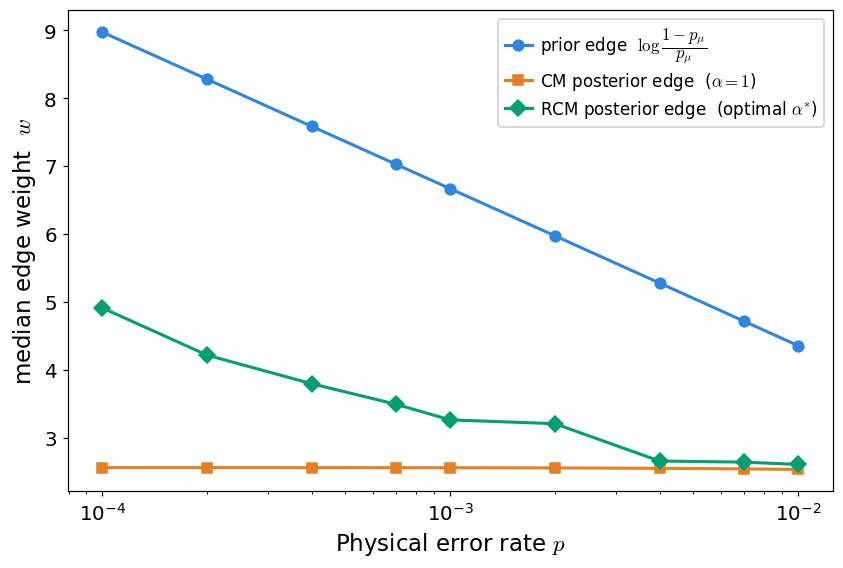

prior    : [8.97 8.28 7.59 7.03 6.67 5.98 5.28 4.72 4.36]
CM  a=1  : [2.56 2.56 2.56 2.56 2.56 2.56 2.55 2.55 2.54]
RCM a*   : [4.91 4.22 3.8  3.5  3.27 3.21 2.66 2.64 2.61]


In [2]:
def median_prior(g):
    p = np.asarray(g.base_p); p = p[(p > 0) & (p < 1)]
    return np.median(np.log((1.0 - p) / p))


def median_posterior(g, alpha):
    "Median over correlated edge-pairs of w = log((1-p_imp)/p_imp), p_imp the Pearl mix (fork math)."
    occ = np.asarray(g.base_p); corr = np.asarray(g.initial_corr_tracer)
    src, dst = np.asarray(g.line_edge_index)
    Pv, Pmu, Pmv = occ[dst], occ[src], corr                 # P(nu), P(mu), P(mu, nu)
    v = (Pv > 0) & (Pv < 1) & (Pmv > 0)
    pc = Pmv[v] / Pv[v]                                      # P(mu | nu)  (hard evidence)
    pn = np.clip((Pmu[v] - Pmv[v]) / (1.0 - Pv[v]), 0.0, None)   # P(mu | ~nu)
    imp = np.clip(alpha * pc + (1.0 - alpha) * pn, 1e-6, 0.499999)
    return np.median(np.log((1.0 - imp) / imp))


PS = sorted(df[df.distance == 5].p.unique())                # the scan's d=5 grid (1e-4 ... 1e-2)
prior, post1, posta, alphas = [], [], [], []
for P in PS:
    g = DecodingGraph.from_dem(build(5, P)[1]); a = best_alpha(5, P); alphas.append(a)
    prior.append(median_prior(g)); post1.append(median_posterior(g, 1.0)); posta.append(median_posterior(g, a))
PS = np.array(PS); prior, post1, posta = map(np.array, (prior, post1, posta))
print("alpha*(p):", dict(zip([f'{p:g}' for p in PS], alphas)))

fig, ax = plt.subplots(figsize=(7.8, 5.3))
ax.plot(PS, prior, "o-", color="#2e86de", lw=2.0, ms=7,
        label=r"prior edge  $\log\dfrac{1-p_\mu}{p_\mu}$")
ax.plot(PS, post1, "s-", color="#e67e22", lw=2.0, ms=7,
        label=r"CM posterior edge  ($\alpha=1$)")
ax.plot(PS, posta, "D-", color="#009E73", lw=2.0, ms=7,
        label=r"RCM posterior edge  (optimal $\alpha^{*}$)")
ax.set_xscale("log")
ax.set_xlabel("Physical error rate $p$", fontsize=15)
ax.set_ylabel(r"median edge weight  $w$", fontsize=15)
ax.tick_params(labelsize=13)
ax.legend(fontsize=11, loc="upper right", framealpha=1.0, edgecolor="0.8",
          borderpad=0.4, labelspacing=0.35, handlelength=1.6, handletextpad=0.5)
fig.tight_layout()
savepair(fig, "reg_cm_scale_invariance_bestalpha")
plt.show()
print("prior    :", np.round(prior, 2))
print("CM  a=1  :", np.round(post1, 2))
print("RCM a*   :", np.round(posta, 2))

## 2. Confusing low-weight configurations: CM($\alpha=1$) vs RCM($\alpha^{*}$) vs MWPM

Same enumeration as the hard-CM notebook, now decoding with the optimal $\alpha^{*}(p)$ as well.
**Left ($d=5$, weight-2, exhaustive):** RCM($\alpha^{*}$) removes almost all of CM's failures — and
the residual count *falls* toward low $p$ (opposite to CM). **Right ($d=7$, weight-3, sampled):**
RCM($\alpha^{*}$)'s estimated count is far below CM($\alpha=1$)'s. MWPM stays at $0$ throughout. The
$d=7$ CM($\alpha=1$) curve is reused from the hard-CM run; the RCM($\alpha^{*}$) curve is sampled
here ($N\sim9\times10^{6}$ hyperedge triples per $p$, scaled by $\binom{|H|}{3}$, Poisson bars).

In [3]:
def count_2fault(D, P, alpha):
    "Exhaustive weight-2: (#CM/RCM failures at this alpha, #MWPM failures)."
    circ, dem, mwpm, cm = build(D, P)
    mechs, dm, ob, hyper = mechanisms(dem); M = len(mechs)
    cf = mf = 0
    for i0 in range(0, M, 400):
        blocks, ii, jj = [], [], []
        for a in range(i0, min(i0 + 400, M)):
            b = np.arange(a + 1, M)
            if b.size:
                blocks.append(dm[a] ^ dm[a + 1:]); ii.append(np.full(b.size, a)); jj.append(b)
        if not blocks:
            continue
        s = np.vstack(blocks); ii = np.concatenate(ii); jj = np.concatenate(jj); obo = ob[ii] ^ ob[jj]
        pm = mwpm.decode_batch(s)[:, 0]; c = cm.decode_batch(s, enable_correlations=True, alpha=alpha)[:, 0]
        cf += int((c != obo).sum()); mf += int((pm != obo).sum())
    return cf, mf


def count_3fault_sampled(D, P, alpha, budget=90.0, seed=0):
    "Sampled weight-3 over all-hyperedge triples, scaled by C(H,3). Returns (cm_est, cm_err, hits)."
    circ, dem, mwpm, cm = build(D, P)
    mechs, dm, ob, hyper = mechanisms(dem)
    H = np.flatnonzero(hyper); nH = len(H); nTri = nH * (nH - 1) * (nH - 2) / 6.0
    rng = np.random.default_rng(seed)
    tot = cmf = 0; t0 = time.time()
    while time.time() - t0 < budget:
        B = 400000
        ii = rng.choice(H, B); jj = rng.choice(H, B); kk = rng.choice(H, B)
        ok = (ii != jj) & (jj != kk) & (ii != kk); ii, jj, kk = ii[ok], jj[ok], kk[ok]
        s = dm[ii] ^ dm[jj] ^ dm[kk]; obo = ob[ii] ^ ob[jj] ^ ob[kk]
        c = cm.decode_batch(s, enable_correlations=True, alpha=alpha)[:, 0]
        tot += len(ii); cmf += int((c != obo).sum())
    est = cmf / tot * nTri
    return est, est / np.sqrt(max(cmf, 1)), cmf


PS5 = [2e-3, 1e-3, 4e-4, 2e-4, 1e-4]
PS7 = [2e-3, 1e-3, 4e-4, 2e-4, 1e-4]
CACHE = os.path.join(DATA, "cm_lowweight_counts_bestalpha_d5_d7.npz")
BASE = os.path.join(DATA, "cm_lowweight_counts_d5_d7.npz")   # hard-CM run (for the d=7 alpha=1 curve)

if os.path.exists(CACHE):
    z = np.load(CACHE)
    P5, cm5_1, cm5_a, mw5 = z["P5"], z["cm5_1"], z["cm5_a"], z["mw5"]
    P7, cm7_1, cm7_1e, cm7_a, cm7_ae, mw7 = (z["P7"], z["cm7_1"], z["cm7_1e"],
                                             z["cm7_a"], z["cm7_ae"], z["mw7"])
    print("loaded cached best-alpha counts from", CACHE)
else:
    # ---- d=5 weight-2, exhaustive: CM(alpha=1) and RCM(alpha*) (MWPM computed once) ----
    cm5_1, cm5_a, mw5 = [], [], []
    print("d=5 weight-2 (exhaustive)")
    print(f"{'p':>8} {'a*':>4} {'CM a=1':>8} {'RCM a*':>8} {'MWPM':>6}")
    for P in PS5:
        a = best_alpha(5, P)
        c1, m = count_2fault(5, P, 1.0); ca, _ = count_2fault(5, P, a)
        cm5_1.append(c1); cm5_a.append(ca); mw5.append(m)
        print(f"{P:>8g} {a:>4} {c1:>8} {ca:>8} {m:>6}")

    # ---- d=7 weight-3: reuse hard-CM alpha=1 curve; sample alpha* here ----
    if os.path.exists(BASE):
        b = np.load(BASE)
        m1 = {round(float(p), 9): (float(e), float(s), float(mw))
              for p, e, s, mw in zip(b["P7"], b["cm7"], b["cm7e"], b["mw7"])}
        cm7_1 = [m1[round(P, 9)][0] for P in PS7]
        cm7_1e = [m1[round(P, 9)][1] for P in PS7]
        mw7 = [m1[round(P, 9)][2] for P in PS7]
    else:
        raise FileNotFoundError("run cm_vs_mwpm_confusion.ipynb first to make " + BASE)
    cm7_a, cm7_ae = [], []
    print("\nd=7 weight-3 (sampled RCM alpha*)")
    print(f"{'p':>8} {'a*':>4} {'RCM est':>12} {'+/-':>10} {'hits':>6}")
    for P in PS7:
        a = best_alpha(7, P)
        e, err, hits = count_3fault_sampled(7, P, a)
        cm7_a.append(e); cm7_ae.append(err)
        print(f"{P:>8g} {a:>4} {e:>12,.0f} {err:>10,.0f} {hits:>6}")

    P5 = np.array(PS5); P7 = np.array(PS7)
    cm5_1, cm5_a, mw5 = map(np.array, (cm5_1, cm5_a, mw5))
    cm7_1, cm7_1e, cm7_a, cm7_ae, mw7 = map(np.array, (cm7_1, cm7_1e, cm7_a, cm7_ae, mw7))
    np.savez(CACHE, P5=P5, cm5_1=cm5_1, cm5_a=cm5_a, mw5=mw5,
             P7=P7, cm7_1=cm7_1, cm7_1e=cm7_1e, cm7_a=cm7_a, cm7_ae=cm7_ae, mw7=mw7)
    print("saved best-alpha counts to", CACHE)

loaded cached best-alpha counts from C:\Users\cesar\Documents\Python\master-thesis\Master-thesis-RL-QEC\data\cm_lowweight_counts_bestalpha_d5_d7.npz


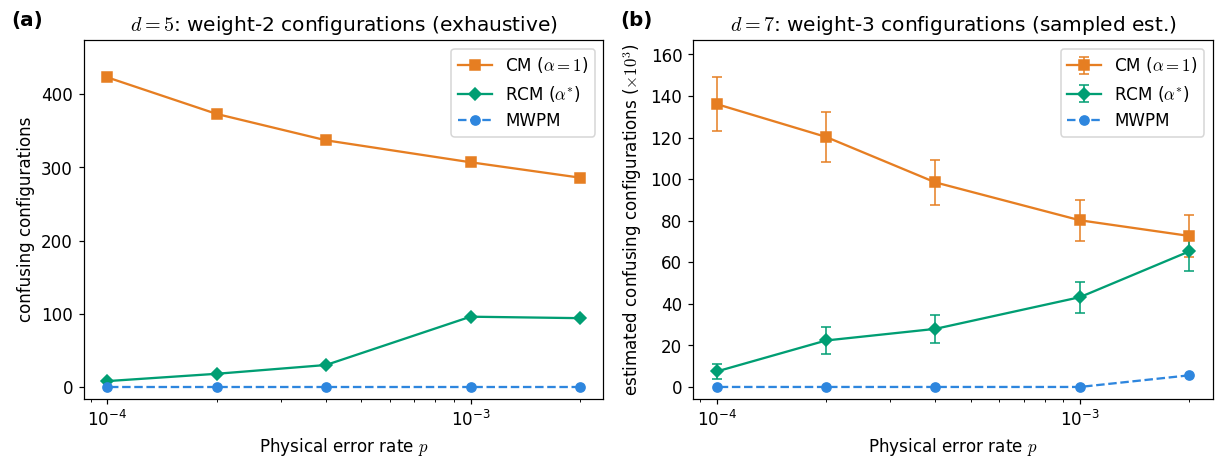

In [4]:
C_CM, C_RCM, C_MW = "#e67e22", "#009E73", "#2e86de"
fig, (a5, a7) = plt.subplots(1, 2, figsize=(11.2, 4.4))

a5.plot(P5, cm5_1, "s-", color=C_CM, label=r"CM ($\alpha=1$)")
a5.plot(P5, cm5_a, "D-", color=C_RCM, label=r"RCM ($\alpha^{*}$)")
a5.plot(P5, mw5, "o--", color=C_MW, label="MWPM")
a5.set_title(r"$d=5$: weight-2 configurations (exhaustive)")
a5.set_ylabel("confusing configurations")

h_cm7 = a7.errorbar(P7, cm7_1 / 1e3, yerr=cm7_1e / 1e3, marker="s", ls="-", color=C_CM,
                    capsize=3, elinewidth=1.0, label=r"CM ($\alpha=1$)")
h_rcm7 = a7.errorbar(P7, cm7_a / 1e3, yerr=cm7_ae / 1e3, marker="D", ls="-", color=C_RCM,
                     capsize=3, elinewidth=1.0, label=r"RCM ($\alpha^{*}$)")
h_mw7, = a7.plot(P7, mw7 / 1e3, "o--", color=C_MW, label="MWPM")
a7.set_title(r"$d=7$: weight-3 configurations (sampled est.)")
a7.set_ylabel(r"estimated confusing configurations ($\times 10^{3}$)")

a5.legend()
a7.legend([h_cm7, h_rcm7, h_mw7], ["CM ($\\alpha=1$)", "RCM ($\\alpha^{*}$)", "MWPM"])
for ax, lab in zip((a5, a7), "ab"):
    ax.set_xscale("log"); ax.set_xlabel("Physical error rate $p$")
    ax.margins(y=0.12)
    hi = ax.get_ylim()[1]
    ax.set_ylim(-0.035 * hi, hi)
    ax.text(-0.14, 1.04, f"({lab})", transform=ax.transAxes, fontsize=13, fontweight="bold")
fig.tight_layout()
savepair(fig, "reg_cm_vs_cm_lowweight_counts_d5_d7")
plt.show()

## 3. Low-$p$ law: does $w^{\mathrm{RCM}}$ regrow as $k\log\frac{1}{p}+c$? ($d=5$)

We fit the RCM($\alpha^{*}$) posterior weight at the **five lowest** $p$ to $k\log\frac{1}{p}+c$. A
slope $k<1$ (vs the prior's slope $1$) means damping makes the posterior weight **partly regrow** like
the prior — restoring a fraction $k$ of the lost scaling. The intercept comes out $c\approx-1.6$, **not
$\approx0$**: a pure $k\log\frac1p$ misses a constant offset, because the true constant term is
$w^{\mathrm{CM}}$ (§4), not zero.

RCM low-p fit:  k*log(1/p)     ->  k = 0.498   R^2 = 0.904
                k*log(1/p) + b  ->  k = 0.693   b = -1.564   R^2 = 0.983
                prior slope     =  1.000  (reference, expect 1)
                alpha* power law:  alpha* ~ p^0.67


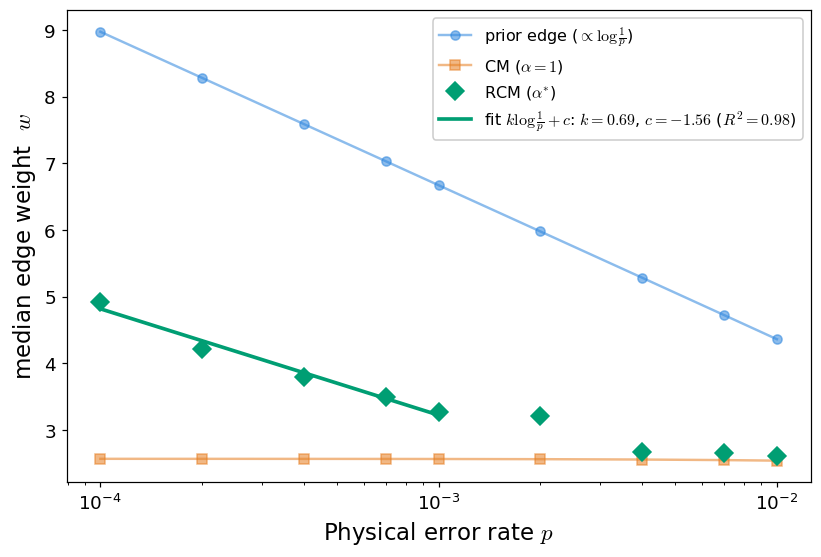

In [5]:
PSd5 = np.array(sorted(df[df.distance == 5].p.unique()))
prior5, post1_5, posta5, al5 = [], [], [], []
for P in PSd5:
    g = DecodingGraph.from_dem(build(5, P)[1]); a = best_alpha(5, P); al5.append(a)
    prior5.append(median_prior(g)); post1_5.append(median_posterior(g, 1.0)); posta5.append(median_posterior(g, a))
prior5, post1_5, posta5, al5 = map(np.array, (prior5, post1_5, posta5, al5))
Lg = np.log(1.0 / PSd5)


def r2(y, yh):
    yh = np.asarray(yh); return 1.0 - np.sum((y - yh) ** 2) / np.sum((y - np.mean(y)) ** 2)


lo = np.argsort(PSd5)[:5]                                   # the 5 lowest-p points
k0 = float(np.sum(Lg[lo] * posta5[lo]) / np.sum(Lg[lo] ** 2))            # w = k log(1/p)
(k1, b1), *_ = np.linalg.lstsq(np.vstack([Lg[lo], np.ones(5)]).T, posta5[lo], rcond=None)
print(f"RCM low-p fit:  k*log(1/p)     ->  k = {k0:.3f}   R^2 = {r2(posta5[lo], k0*Lg[lo]):.3f}")
print(f"                k*log(1/p) + b  ->  k = {k1:.3f}   b = {b1:.3f}   R^2 = {r2(posta5[lo], k1*Lg[lo]+b1):.3f}")
print(f"                prior slope     =  {np.polyfit(Lg[lo], prior5[lo], 1)[0]:.3f}  (reference, expect 1)")
print(f"                alpha* power law:  alpha* ~ p^{np.polyfit(Lg[lo], -np.log(al5[lo]), 1)[0]:.2f}")

fig, ax = plt.subplots(figsize=(7.6, 5.2))
ax.plot(PSd5, prior5, "o-", color="#2e86de", lw=1.6, ms=6, alpha=0.55, label=r"prior edge ($\propto\log\frac{1}{p}$)")
ax.plot(PSd5, post1_5, "s-", color="#e67e22", lw=1.6, ms=6, alpha=0.55, label=r"CM ($\alpha=1$)")
ax.plot(PSd5, posta5, "D", color="#009E73", ms=8, label=r"RCM ($\alpha^{*}$)")
pg = np.geomspace(PSd5[lo].min(), PSd5[lo].max(), 50)
ax.plot(pg, k1 * np.log(1.0 / pg) + b1, "-", color="#009E73", lw=2.4,
        label=rf"fit $k\log\frac{{1}}{{p}}+c$: $k={k1:.2f}$, $c={b1:.2f}$ ($R^2={r2(posta5[lo], k1*Lg[lo]+b1):.2f}$)")
ax.set_xscale("log")
ax.set_xlabel("Physical error rate $p$", fontsize=15)
ax.set_ylabel(r"median edge weight  $w$", fontsize=15)
ax.tick_params(labelsize=12)
ax.legend(fontsize=10.5, loc="upper right", framealpha=1.0, edgecolor="0.8")
fig.tight_layout()
savepair(fig, "reg_cm_bestalpha_klogp_fit")
plt.show()

## 4. Decomposition $w^{\mathrm{RCM}}\approx-\log\alpha^{*}+w^{\mathrm{CM}}$, and what $w'$ really is

At low $p$/small $\alpha$ the reweighted probability is dominated by the conditional term,
$p_{\text{imp}}\approx\alpha\,P(e_\mu|e_\nu)$, so
$$w^{\mathrm{RCM}}_\mu \approx -\log\alpha^{*} - \log P(e_\mu|e_\nu) \approx -\log\alpha^{*} + w^{\mathrm{CM}}_\mu ,
  \qquad w^{\mathrm{CM}}_\mu=\log\tfrac{1-P(e_\mu|e_\nu)}{P(e_\mu|e_\nu)} .$$
We test this by plotting the **residual** $w'_\mu \equiv w^{\mathrm{RCM}}+\log\alpha^{*}$. It lands
**exactly on $w^{\mathrm{CM}}$** (flat $\approx2.56$), confirming the decomposition. Note this means
$w'_\mu = w^{\mathrm{CM}}_\mu$ — the residual is **not** the median (prior) edge weight, which is much
larger (4.4–9.0). Since $\alpha^{*}\!\approx\!(p/p_{\rm th})^{k}$, one can also write
$w^{\mathrm{RCM}}\approx k\log\frac1p+\big(w^{\mathrm{CM}}-k\log\frac1{p_{\rm th}}\big)$: the constant
offset is $k$ times the prior weight *at the pseudo-threshold*, equal to the median edge weight only
in the (untrue) limit $k=1$.

p         w_CM(a=1)   -log a*   w_RCM    residual=w_RCM+log a*   (residual - w_CM)
0.0001       2.56      2.30     4.91           2.61             +0.05
0.0002       2.56      1.61     4.22           2.61             +0.05
0.0004       2.56      1.20     3.80           2.59             +0.03
0.0007       2.56      0.92     3.50           2.58             +0.02
0.001        2.56      0.69     3.27           2.57             +0.01
0.002        2.56      0.69     3.21           2.52             -0.04
0.004        2.55      0.11     2.66           2.56             +0.00
0.007        2.55      0.11     2.64           2.54             -0.01
0.01         2.54      0.11     2.61           2.51             -0.03


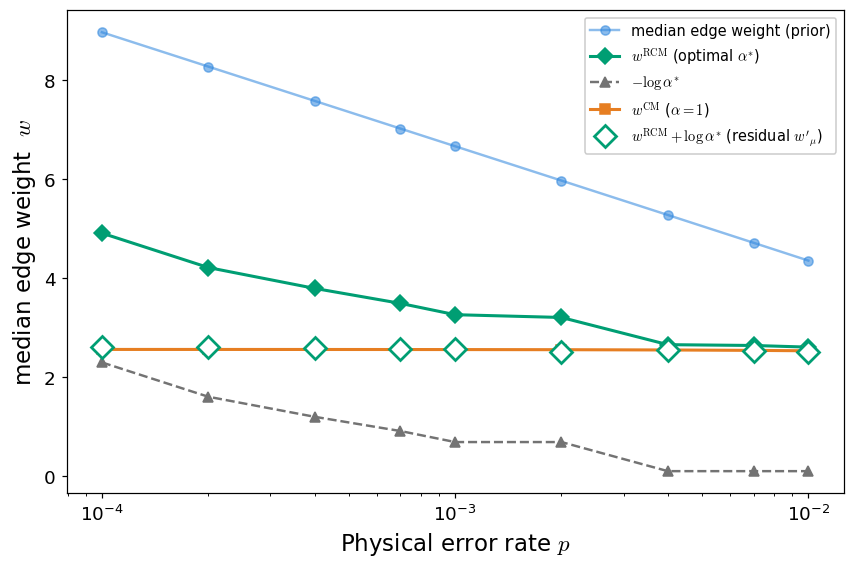

In [6]:
resid = posta5 + np.log(al5)                                # w_RCM - (-log alpha*)  = w'_mu
print("p         w_CM(a=1)   -log a*   w_RCM    residual=w_RCM+log a*   (residual - w_CM)")
for P, wc, a, wr, r in zip(PSd5, post1_5, al5, posta5, resid):
    print(f"{P:<8g}  {wc:>7.2f}   {-np.log(a):>7.2f}   {wr:>6.2f}        {r:>7.2f}            {r-wc:>+6.2f}")

fig, ax = plt.subplots(figsize=(7.9, 5.3))
ax.plot(PSd5, prior5, "o-", color="#2e86de", lw=1.6, ms=6, alpha=0.55, label=r"median edge weight (prior)")
ax.plot(PSd5, posta5, "D-", color="#009E73", lw=2.0, ms=7, label=r"$w^{\mathrm{RCM}}$ (optimal $\alpha^{*}$)")
ax.plot(PSd5, -np.log(al5), "^--", color="0.45", lw=1.6, ms=7, label=r"$-\log\alpha^{*}$")
ax.plot(PSd5, post1_5, "s-", color="#e67e22", lw=2.0, ms=7, label=r"$w^{\mathrm{CM}}$ ($\alpha=1$)")
ax.plot(PSd5, resid, "D", mfc="white", mec="#009E73", mew=1.8, ms=10,
        label=r"$w^{\mathrm{RCM}}+\log\alpha^{*}$ (residual $w'_\mu$)")
ax.set_xscale("log")
ax.set_xlabel("Physical error rate $p$", fontsize=15)
ax.set_ylabel(r"median edge weight  $w$", fontsize=15)
ax.tick_params(labelsize=12)
ax.legend(fontsize=9.5, loc="upper right", framealpha=1.0, edgecolor="0.8")
fig.tight_layout()
savepair(fig, "reg_cm_bestalpha_decomposition")
plt.show()

## 5. Is $w'$ the median edge weight? A per-pair test

The proposed identity $w^{\mathrm{RCM}}_\mu = k\log\frac1p + (w^{\mathrm{CM}}_\mu - w')$ with
$w'=\overline{w}(p)$ (the median prior edge weight) is equivalent to
$$y_\mu \equiv w^{\mathrm{RCM}}_\mu - w^{\mathrm{CM}}_\mu + \overline{w}(p) = k\log\tfrac1p + c,
  \qquad c\approx 0 .$$
We fit this over **all** correlated edge-pairs at every $p$ ($d=5$). The intercept comes out
$c\approx-2.7$ (all $p$; $\approx-4.4$ at low $p$) — **not $0$** — so $w'$ is *not* the median edge
weight. The reason: per-pair $w^{\mathrm{RCM}}_\mu-w^{\mathrm{CM}}_\mu\approx-\log\alpha^{*}$, so
$y_\mu\approx-\log\alpha^{*}+\overline{w}(p)$ with slope $k\approx1+k_\alpha\approx1.5$ and offset
$-\log(\text{prefactor of }\alpha^{*})\neq0$. The constant term that *does* work is $w^{\mathrm{CM}}$
(§4), i.e. $w'\approx0$.

per-pair fit  y = w_RCM - w_CM + median_weight  ~  k log(1/p) + c   (10575 pairs)
   k = 1.487   c = -2.667   R^2 = 0.989
   c = -2.67 is NOT ~0  ->  w' is not the median edge weight (the working constant is w_CM).


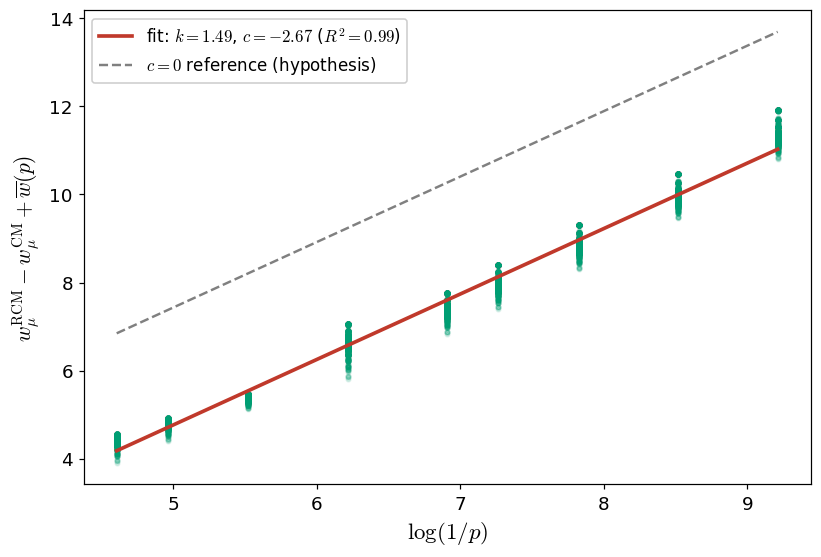

In [7]:
Yv, Xv = [], []
for P in PSd5:
    g = DecodingGraph.from_dem(build(5, P)[1]); a = best_alpha(5, P)
    occ = np.asarray(g.base_p); corr = np.asarray(g.initial_corr_tracer); src, dst = np.asarray(g.line_edge_index)
    Pv, Pmu, Pmv = occ[dst], occ[src], corr
    v = (Pv > 0) & (Pv < 1) & (Pmv > 0)
    pc = np.clip(Pmv[v] / Pv[v], 1e-6, 0.499999)
    pn = np.clip((Pmu[v] - Pmv[v]) / (1.0 - Pv[v]), 0.0, None)
    wcm = np.log((1.0 - pc) / pc)
    imp = np.clip(a * pc + (1.0 - a) * pn, 1e-6, 0.499999); wrcm = np.log((1.0 - imp) / imp)
    pe = occ[(occ > 0) & (occ < 1)]; wbar = np.median(np.log((1.0 - pe) / pe))
    Yv.append(wrcm - wcm + wbar); Xv.append(np.full(int(v.sum()), np.log(1.0 / P)))
Yv = np.concatenate(Yv); Xv = np.concatenate(Xv)
(kk, cc), *_ = np.linalg.lstsq(np.vstack([Xv, np.ones_like(Xv)]).T, Yv, rcond=None)
print(f"per-pair fit  y = w_RCM - w_CM + median_weight  ~  k log(1/p) + c   ({len(Yv)} pairs)")
print(f"   k = {kk:.3f}   c = {cc:.3f}   R^2 = {r2(Yv, kk*Xv + cc):.3f}")
print(f"   c = {cc:.2f} is NOT ~0  ->  w' is not the median edge weight (the working constant is w_CM).")

fig, ax = plt.subplots(figsize=(7.6, 5.2))
ax.plot(Xv, Yv, "o", color="#009E73", ms=3, alpha=0.12)
xg = np.linspace(Xv.min(), Xv.max(), 50)
ax.plot(xg, kk * xg + cc, "-", color="#c0392b", lw=2.4,
        label=rf"fit: $k={kk:.2f}$, $c={cc:.2f}$ ($R^2={r2(Yv, kk*Xv+cc):.2f}$)")
ax.plot(xg, kk * xg, "--", color="0.5", lw=1.6, label=r"$c=0$ reference (hypothesis)")
ax.set_xlabel(r"$\log(1/p)$", fontsize=15)
ax.set_ylabel(r"$w^{\mathrm{RCM}}_\mu - w^{\mathrm{CM}}_\mu + \overline{w}(p)$", fontsize=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=11, loc="upper left", framealpha=1.0, edgecolor="0.8")
fig.tight_layout()
savepair(fig, "reg_cm_bestalpha_median_hypothesis")
plt.show()

## 6. The dependence on $w^{\mathrm{CM}}_\mu$: $\;w^{\mathrm{RCM}}_\mu = w^{\mathrm{CM}}_\mu - \log\alpha^{*}(p)$

Per edge-pair, RCM **keeps CM's weight and adds one $p$-dependent shift** $-\log\alpha^{*}$.
**(a)** $w^{\mathrm{RCM}}_\mu$ vs $w^{\mathrm{CM}}_\mu$ coloured by $p$: the clouds lie on **parallel
unit-slope lines**, each offset by $-\log\alpha^{*}(p)$. **(b)** the gap
$w^{\mathrm{RCM}}_\mu-w^{\mathrm{CM}}_\mu$ collapses onto $-\log\alpha^{*}(p)$ and, since
$\alpha^{*}\!\approx\!(p/p_{\rm th})^{k}$, fits $k\log\frac{1}{p}+c_0$ with $k\approx0.67$,
$c_0\approx-4$. The grey $c_0=0$ line (the *bare* $k\log\frac1p+w^{\mathrm{CM}}$) misses by $\approx4$:
the constant $c_0=-k\log\frac1{p_{\rm th}}$ cannot be dropped.

unit-slope model  w_RCM = w_CM - log(alpha*) :  R^2 = 0.9858
gap fit  w_RCM - w_CM = k log(1/p) + c0 :  k = 0.485, c0 = -2.416, R^2 = 0.906


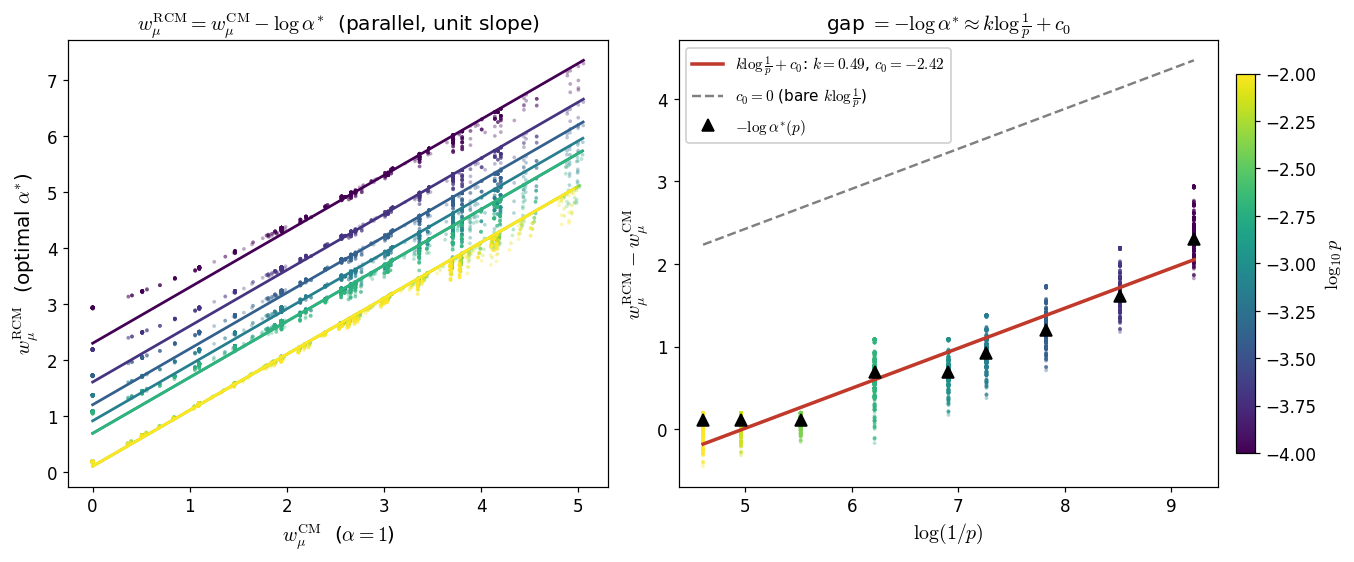

In [8]:
import matplotlib as mpl

WC, WR, PPl, off = [], [], [], {}
for P in PSd5:
    g = DecodingGraph.from_dem(build(5, P)[1]); a = best_alpha(5, P); off[P] = -np.log(a)
    occ = np.asarray(g.base_p); corr = np.asarray(g.initial_corr_tracer); src, dst = np.asarray(g.line_edge_index)
    Pv, Pmu, Pmv = occ[dst], occ[src], corr; v = (Pv > 0) & (Pv < 1) & (Pmv > 0)
    pc = np.clip(Pmv[v] / Pv[v], 1e-6, 0.499999); pn = np.clip((Pmu[v] - Pmv[v]) / (1.0 - Pv[v]), 0.0, None)
    wcm = np.log((1.0 - pc) / pc); imp = np.clip(a * pc + (1.0 - a) * pn, 1e-6, 0.499999)
    WC.append(wcm); WR.append(np.log((1.0 - imp) / imp)); PPl.append(np.full(int(v.sum()), float(P)))
WC = np.concatenate(WC); WR = np.concatenate(WR); PPl = np.concatenate(PPl); Lp = np.log(1.0 / PPl)

offv = np.vectorize(off.get)(PPl)                                                   # -log(alpha*) per pair
print(f"unit-slope model  w_RCM = w_CM - log(alpha*) :  R^2 = {r2(WR, WC + offv):.4f}")
(kk, c0), *_ = np.linalg.lstsq(np.vstack([Lp, np.ones_like(Lp)]).T, WR - WC, rcond=None)
print(f"gap fit  w_RCM - w_CM = k log(1/p) + c0 :  k = {kk:.3f}, c0 = {c0:.3f}, R^2 = {r2(WR - WC, kk*Lp + c0):.3f}")

cmap = plt.get_cmap("viridis")
norm = mpl.colors.Normalize(np.log10(PSd5.min()), np.log10(PSd5.max()))
fig, (aA, aB) = plt.subplots(1, 2, figsize=(12.2, 5.0), constrained_layout=True)

aA.scatter(WC, WR, c=np.log10(PPl), cmap=cmap, norm=norm, s=6, alpha=0.35, linewidths=0)
for P in PSd5:
    xr = np.array([WC[PPl == P].min(), WC[PPl == P].max()])
    aA.plot(xr, xr + off[P], "-", color=cmap(norm(np.log10(P))), lw=1.8)
aA.set_xlabel(r"$w^{\mathrm{CM}}_\mu$  ($\alpha=1$)", fontsize=13)
aA.set_ylabel(r"$w^{\mathrm{RCM}}_\mu$  (optimal $\alpha^{*}$)", fontsize=13)
aA.set_title(r"$w^{\mathrm{RCM}}_\mu = w^{\mathrm{CM}}_\mu - \log\alpha^{*}$  (parallel, unit slope)")
aA.tick_params(labelsize=11)

aB.scatter(Lp, WR - WC, c=np.log10(PPl), cmap=cmap, norm=norm, s=6, alpha=0.35, linewidths=0)
xg = np.linspace(Lp.min(), Lp.max(), 50)
aB.plot(xg, kk * xg + c0, "-", color="#c0392b", lw=2.3,
        label=rf"$k\log\frac{{1}}{{p}}+c_0$: $k={kk:.2f}$, $c_0={c0:.2f}$")
aB.plot(xg, kk * xg, "--", color="0.5", lw=1.6, label=r"$c_0=0$ (bare $k\log\frac{1}{p}$)")
aB.plot(np.log(1.0 / PSd5), [off[p] for p in PSd5], "k^", ms=8, label=r"$-\log\alpha^{*}(p)$")
aB.set_xlabel(r"$\log(1/p)$", fontsize=13)
aB.set_ylabel(r"$w^{\mathrm{RCM}}_\mu - w^{\mathrm{CM}}_\mu$", fontsize=13)
aB.set_title(r"gap $=-\log\alpha^{*}\approx k\log\frac{1}{p}+c_0$")
aB.tick_params(labelsize=11)
aB.legend(fontsize=10, loc="upper left", framealpha=1.0, edgecolor="0.8")

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cb = fig.colorbar(sm, ax=[aA, aB], location="right", shrink=0.85, pad=0.015)
cb.set_label(r"$\log_{10} p$", fontsize=12)
savepair(fig, "reg_cm_bestalpha_wrcm_vs_wcm")
plt.show()

## Takeaway

Choosing the optimal $\alpha^{*}(p)$ **restores the missing scaling** of the posterior edge weight
(Fig. 1) and **removes almost all of the low-weight configurations that confuse hard CM** (Fig. 2):
at $d=5$ the weight-2 failure count drops by more than an order of magnitude and stops growing as
$p\to0$, and at $d=7$ the estimated weight-3 count falls correspondingly.

The mechanism is quantitative (Figs. 3&4): $w^{\mathrm{RCM}}\approx-\log\alpha^{*}+w^{\mathrm{CM}}$
(residual flat on $w^{\mathrm{CM}}$ to $\pm0.05$), and since $\alpha^{*}\!\sim\!p^{k}$ with
$k\approx0.5$&ndash;$0.7$, the posterior weight regrows as $k\log\frac1p$ &mdash; recovering a
fraction $k$ of the $\log(1/p)$ scaling (hence of the effective distance) that hard CM had lost,
while MWPM remains the sub-threshold reference at $0$. The residual constant is
$w^{\mathrm{CM}}$, **not** the median prior edge weight.